In [1]:
import os
import sys
# Get the absolute path of the current notebook's directory
notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
sys.path.append(parent_dir)  # Add parent directory to sys.path

# model
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as tg
import torch_scatter
from typing import Dict, Union

# crystal structure data
palette = ['#43AA8B', '#F8961E', '#F94144']
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
# data pre-processing and visualization
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
from scipy.interpolate import interp1d
import math
import e3nn.o3 as o3
from e3nn.util.jit import compile_mode
from e3nn.io import CartesianTensor

# utilities
import time
from mendeleev import element
from tqdm import tqdm
from utils.utils_data import load_data, train_valid_test_split, save_or_load_onehot, build_data, format_chemical_formula
from utils.utils_model_scalar import Network, train, evaluate
import wandb
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.ticker import MaxNLocator

bar_format = '{l_bar}{bar:10}{r_bar}{bar:-10b}'
default_dtype = torch.float64
torch.set_default_dtype(default_dtype)

# Create a colormap based on the number of unique symbols
datasets = ['g', 'y', 'r']
colors = dict(zip(datasets, palette))
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap', [palette[k] for k in [0,2,1]])


# Check device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print('torch device:' , device)


## load data
data_file = '../dataset/symmetrized_dataset_with_bandgap.pkl'
df, species = load_data(data_file)
df = df.reset_index(drop=True)

print('data acquired')

energy_min = 0 #Unit of energy in eV
energy_max = 30 #Unit of energy in eV
nstep = 300 #Number of the energy points

new_x = np.linspace(energy_min, energy_max, nstep)
# Efficiently interpolate all matrices using list comprehension
def interpolate_matrix(matrix, omega):
    """Interpolates the full (3001, 3, 3) matrix along the energy axis."""
    interp = interp1d(omega, matrix, kind='linear', axis=0, fill_value=0, bounds_error=False)
    return interp(new_x) 


# Apply interpolation efficiently
df['rel_permittivity_imag_interp'] = [
    interpolate_matrix(row['rel_permittivity_imag'], row['omega']) for _, row in df.iterrows()
]
# Apply the custom function to create a new column
df['energies_interp'] = df.apply(lambda x: new_x, axis=1)


perm_matrices_tensor = torch.tensor(np.stack(df['rel_permittivity_imag_interp'].values), dtype=torch.float64, device=device)

# Transform Cartesian tensor to irreps
cart_and_irreps = CartesianTensor("ij=ji")  # Symmetric rank-2 tensor
sph_coefs_tensor = cart_and_irreps.from_cartesian(perm_matrices_tensor)  # Shape: (num_samples, 301, 6)

df['sph_coefs'] = list(sph_coefs_tensor.cpu().numpy())  # Move to CPU and store as list

type_onehot, mass_onehot, dipole_onehot, radius_onehot, type_encoding = save_or_load_onehot()
# Find the scaling value
tmp = np.array([df.iloc[i]['sph_coefs'] for i in range(len(df))])
print("target data shape", tmp.shape)

scale_data = np.median(np.max(np.abs(tmp), axis=(1, 2)))
print("target data scaling factor", scale_data)


r_max = 6. # cutoff radius
df['data'] = df.progress_apply(lambda x: build_data(x, 'sph_coefs', scale_data, type_onehot, mass_onehot, dipole_onehot, radius_onehot, type_encoding, r_max), axis=1)


torch device: cuda:0
data acquired
Loading existing data...
target data shape (1432, 300, 6)
target data scaling factor 9.635839423960277


100%|██████████| 1432/1432 [00:22<00:00, 63.38it/s]


In [2]:
run_time = '250909'
with open('../model/idx_train_'+run_time+'.txt', 'r') as f: idx_train = [int(i.split('\n')[0]) for i in f.readlines()]
with open('../model/idx_valid_'+run_time+'.txt', 'r') as f: idx_valid = [int(i.split('\n')[0]) for i in f.readlines()]
with open('../model/idx_test_'+run_time+'.txt', 'r') as f: idx_test = [int(i.split('\n')[0]) for i in f.readlines()]

def get_neighbors(df, idx):
    n = []
    for entry in df.iloc[idx].itertuples():
        N = entry.data.pos.shape[0]
        for i in range(N):
            n.append(len((entry.data.edge_index[0] == i).nonzero()))
    return np.array(n)

n_train = get_neighbors(df, idx_train)
print(n_train.mean())


class NetWrapper(Network):
    def __init__(self, in_dim, em_dim, **kwargs):            
        # override the `reduce_output` keyword to instead perform an averge over atom contributions    
        self.pool = False
        if kwargs['reduce_output'] == True:
            kwargs['reduce_output'] = False
            self.pool = True
            
        super().__init__(**kwargs)

        self.em_z = nn.Linear(in_dim, em_dim)    #Linear layer for atom type
        self.em_x = nn.Linear(in_dim, em_dim)    #Linear layer for atom type

    def forward(self, data: Union[tg.data.Data, Dict[str, torch.Tensor]]) -> torch.Tensor:
        data.z = F.relu(self.em_z(data.z))
        data.x = F.relu(self.em_x(data.x))

        output = super().forward(data)
        
        # if pool_nodes was set to True, use scatter_mean to aggregate
        if self.pool == True:
            output = torch_scatter.scatter_mean(output, data.batch, dim=0)  # take mean over atoms per example
        return output


out_dim = len(df.iloc[0]['energies_interp'])      # about 200 points
em_dim = 128 

use_batch_norm = False
dropout_prob=0
batch_size = 4
lmax = 2
mul = 32
layers = 2
lr = 1e-2
model = NetWrapper(
    in_dim=118,
    em_dim=em_dim,
    irreps_in=str(em_dim)+"x0e",
    irreps_out="1800x0e",
    irreps_node_attr=str(em_dim)+"x0e",
    layers=layers,
    mul=mul,
    lmax=lmax,
    max_radius=r_max,
    num_neighbors=n_train.mean(),
    reduce_output=True,
    dropout_prob=dropout_prob,
    use_batch_norm = use_batch_norm
)
run_name =  f'TSENN-S_{run_time}_Lmax_{lmax}_Lr_{lr}_bs_{batch_size}_em_{em_dim}_layers_{layers}_mul_{mul}'

wandb.init(
    project="Prediction",  # Change this to your project name
    name=run_name,  # Unique identifier for this run
    config={
    }
)

# predict on all data
model.load_state_dict(torch.load('../model/'+run_name + '_best.torch', map_location=device)['state'])
model.pool = True

dataloader = tg.loader.DataLoader(df['data'].values, batch_size=64)
df['mse'] = 0.
df['y_pred_sph'] = np.empty((len(df), 0)).tolist()

model.to(device)
model.eval()

# weight contribution of each feature
with torch.no_grad():
    i0 = 0
    for i, d in tqdm(enumerate(dataloader), total=len(dataloader), bar_format=bar_format):
        d.to(device)
        output = model(d)
        y_reordered = d.y.permute(0, 2, 1)   # [batch_size, 6, 300]
        y_unrolled = y_reordered.reshape(d.y.size(0), -1)  # [batch_size, 1800]
        output_reshaped = output.view(-1, 6, 300).permute(0, 2, 1)  # → [batch_size, 300, 6]
        loss = F.mse_loss(output, y_unrolled, reduction='none').mean(dim=-1).cpu().numpy() 
        df.loc[i0:i0 + len(d.y) - 1, 'y_pred_sph'] = [[k] for k in output_reshaped.cpu().numpy()]
        # df.loc[i0:i0 + len(d.y) - 1, 'y_pred_sph'] = [out.cpu().numpy() for out in output_reshaped]
        df.loc[i0:i0 + len(d.y) - 1, 'mse'] = loss
        i0 += len(d.y)
        
column = 'rel_permittivity_imag_interp'

df['y_pred_sph'] = df['y_pred_sph'].map(lambda x: x[0]) * scale_data

sph_tensors = torch.tensor(np.stack(df['y_pred_sph'].values))  # (N, F, 6)
cart_tensors = cart_and_irreps.to_cartesian(sph_tensors)                     # (N, F, 3, 3)
df['y_pred_cart'] = list(cart_tensors.numpy())                 # back to list of arrays

# =====================================================
# Prepare true & pred Cartesian tensors
# =====================================================
cart_true = np.stack(df[column].values)        # (N, F, 3, 3)
cart_pred = np.stack(df['y_pred_cart'].values) # (N, F, 3, 3)

cart_true_tensor = torch.tensor(cart_true, dtype=torch.float64)
cart_pred_tensor = torch.tensor(cart_pred, dtype=torch.float64)

# =====================================================
# Component-wise Cartesian MAE
# =====================================================
triu_idx = np.triu_indices(3)  # 6 unique entries
component_labels = ["xx", "xy", "xz", "yy", "yz", "zz"]

def mae_symmetric_components(pred, true):
    """
    pred, true: (N,F,3,3)
    return: (N,F,6) absolute errors for each unique component
    """
    errors = []
    for i, j in zip(triu_idx[0], triu_idx[1]):
        errors.append(torch.abs(pred[:, :, i, j] - true[:, :, i, j]))  # (N,F)
    return torch.stack(errors, dim=2)  # (N,F,6)
def mse_symmetric_components(pred, true):
    """
    pred, true: (N,F,3,3)
    return: (N,F,6) absolute errors for each unique component
    """
    errors = []
    for i, j in zip(triu_idx[0], triu_idx[1]):
        errors.append((pred[:, :, i, j] - true[:, :, i, j])**2)  # (N,F)
    return torch.stack(errors, dim=2)  # (N,F,6)
# Compute errors
mae_cart_tensor_errors = mae_symmetric_components(cart_pred_tensor, cart_true_tensor)  # (N,F,6)
mse_cart_tensor_errors = mse_symmetric_components(cart_pred_tensor, cart_true_tensor)  # (N,F,6)

# Average over frequency → per-sample per-component MAE
mae_cart_components = torch.mean(mae_cart_tensor_errors, dim=1).cpu().numpy()  # (N,6)
mse_cart_components = torch.mean(mse_cart_tensor_errors, dim=1).cpu().numpy() 

# Add per-component columns
for k, label in enumerate(component_labels):
    df[f"mae_cart_{label}"] = mae_cart_components[:, k]
    df[f"mse_cart_{label}"] = mse_cart_components[:, k]
# Add overall mean across 6 components
df["mae_cart"] = mae_cart_components.mean(axis=1)
df["mse_cart"] = mse_cart_components.mean(axis=1)

sph_true = torch.tensor(np.stack(df['sph_coefs'].values), dtype=torch.float64, device=device)  # (N, F, 6)
sph_pred = torch.tensor(np.stack(df['y_pred_sph'].values), device=device) # already normalize

mae_sph = torch.mean(torch.abs(sph_pred - sph_true), dim=(1, 2)).cpu().numpy()  
df['mae_sph'] = mae_sph


mae_sph_mean = df['mae_sph'].mean()
mae_sph_std = df['mae_sph'].std()
mae_cart_mean = df['mae_cart'].mean()
mae_cart_std = df['mae_cart'].std()

wandb.finish()

43.404443289593345


wandb: Currently logged in as: hsu-ting (hsu-ting-northeastern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


100%|██████████| 23/23 [00:04<00:00,  5.72it/s]


In [3]:
mpl.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams["mathtext.fontset"] = "cm"
fontsize = 16
textsize = 16
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['font.size'] = fontsize
plt.rcParams['axes.labelsize'] = textsize 
plt.rcParams['xtick.labelsize'] = textsize  
plt.rcParams['ytick.labelsize'] = textsize
plt.rcParams['legend.fontsize'] = fontsize
plt.rcParams['text.usetex'] = False
plt.rcParams['figure.dpi'] = 150       
plt.rcParams['savefig.dpi'] = 300   

splits = {
    "Train": idx_train,
    "Validation": idx_valid,
    "Test": idx_test
}


df['split'] = np.nan
for split_name, idx in splits.items():
    df.loc[idx, 'split'] = split_name

/tmp/ipykernel_755320/3681721782.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Train' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, 'split'] = split_name


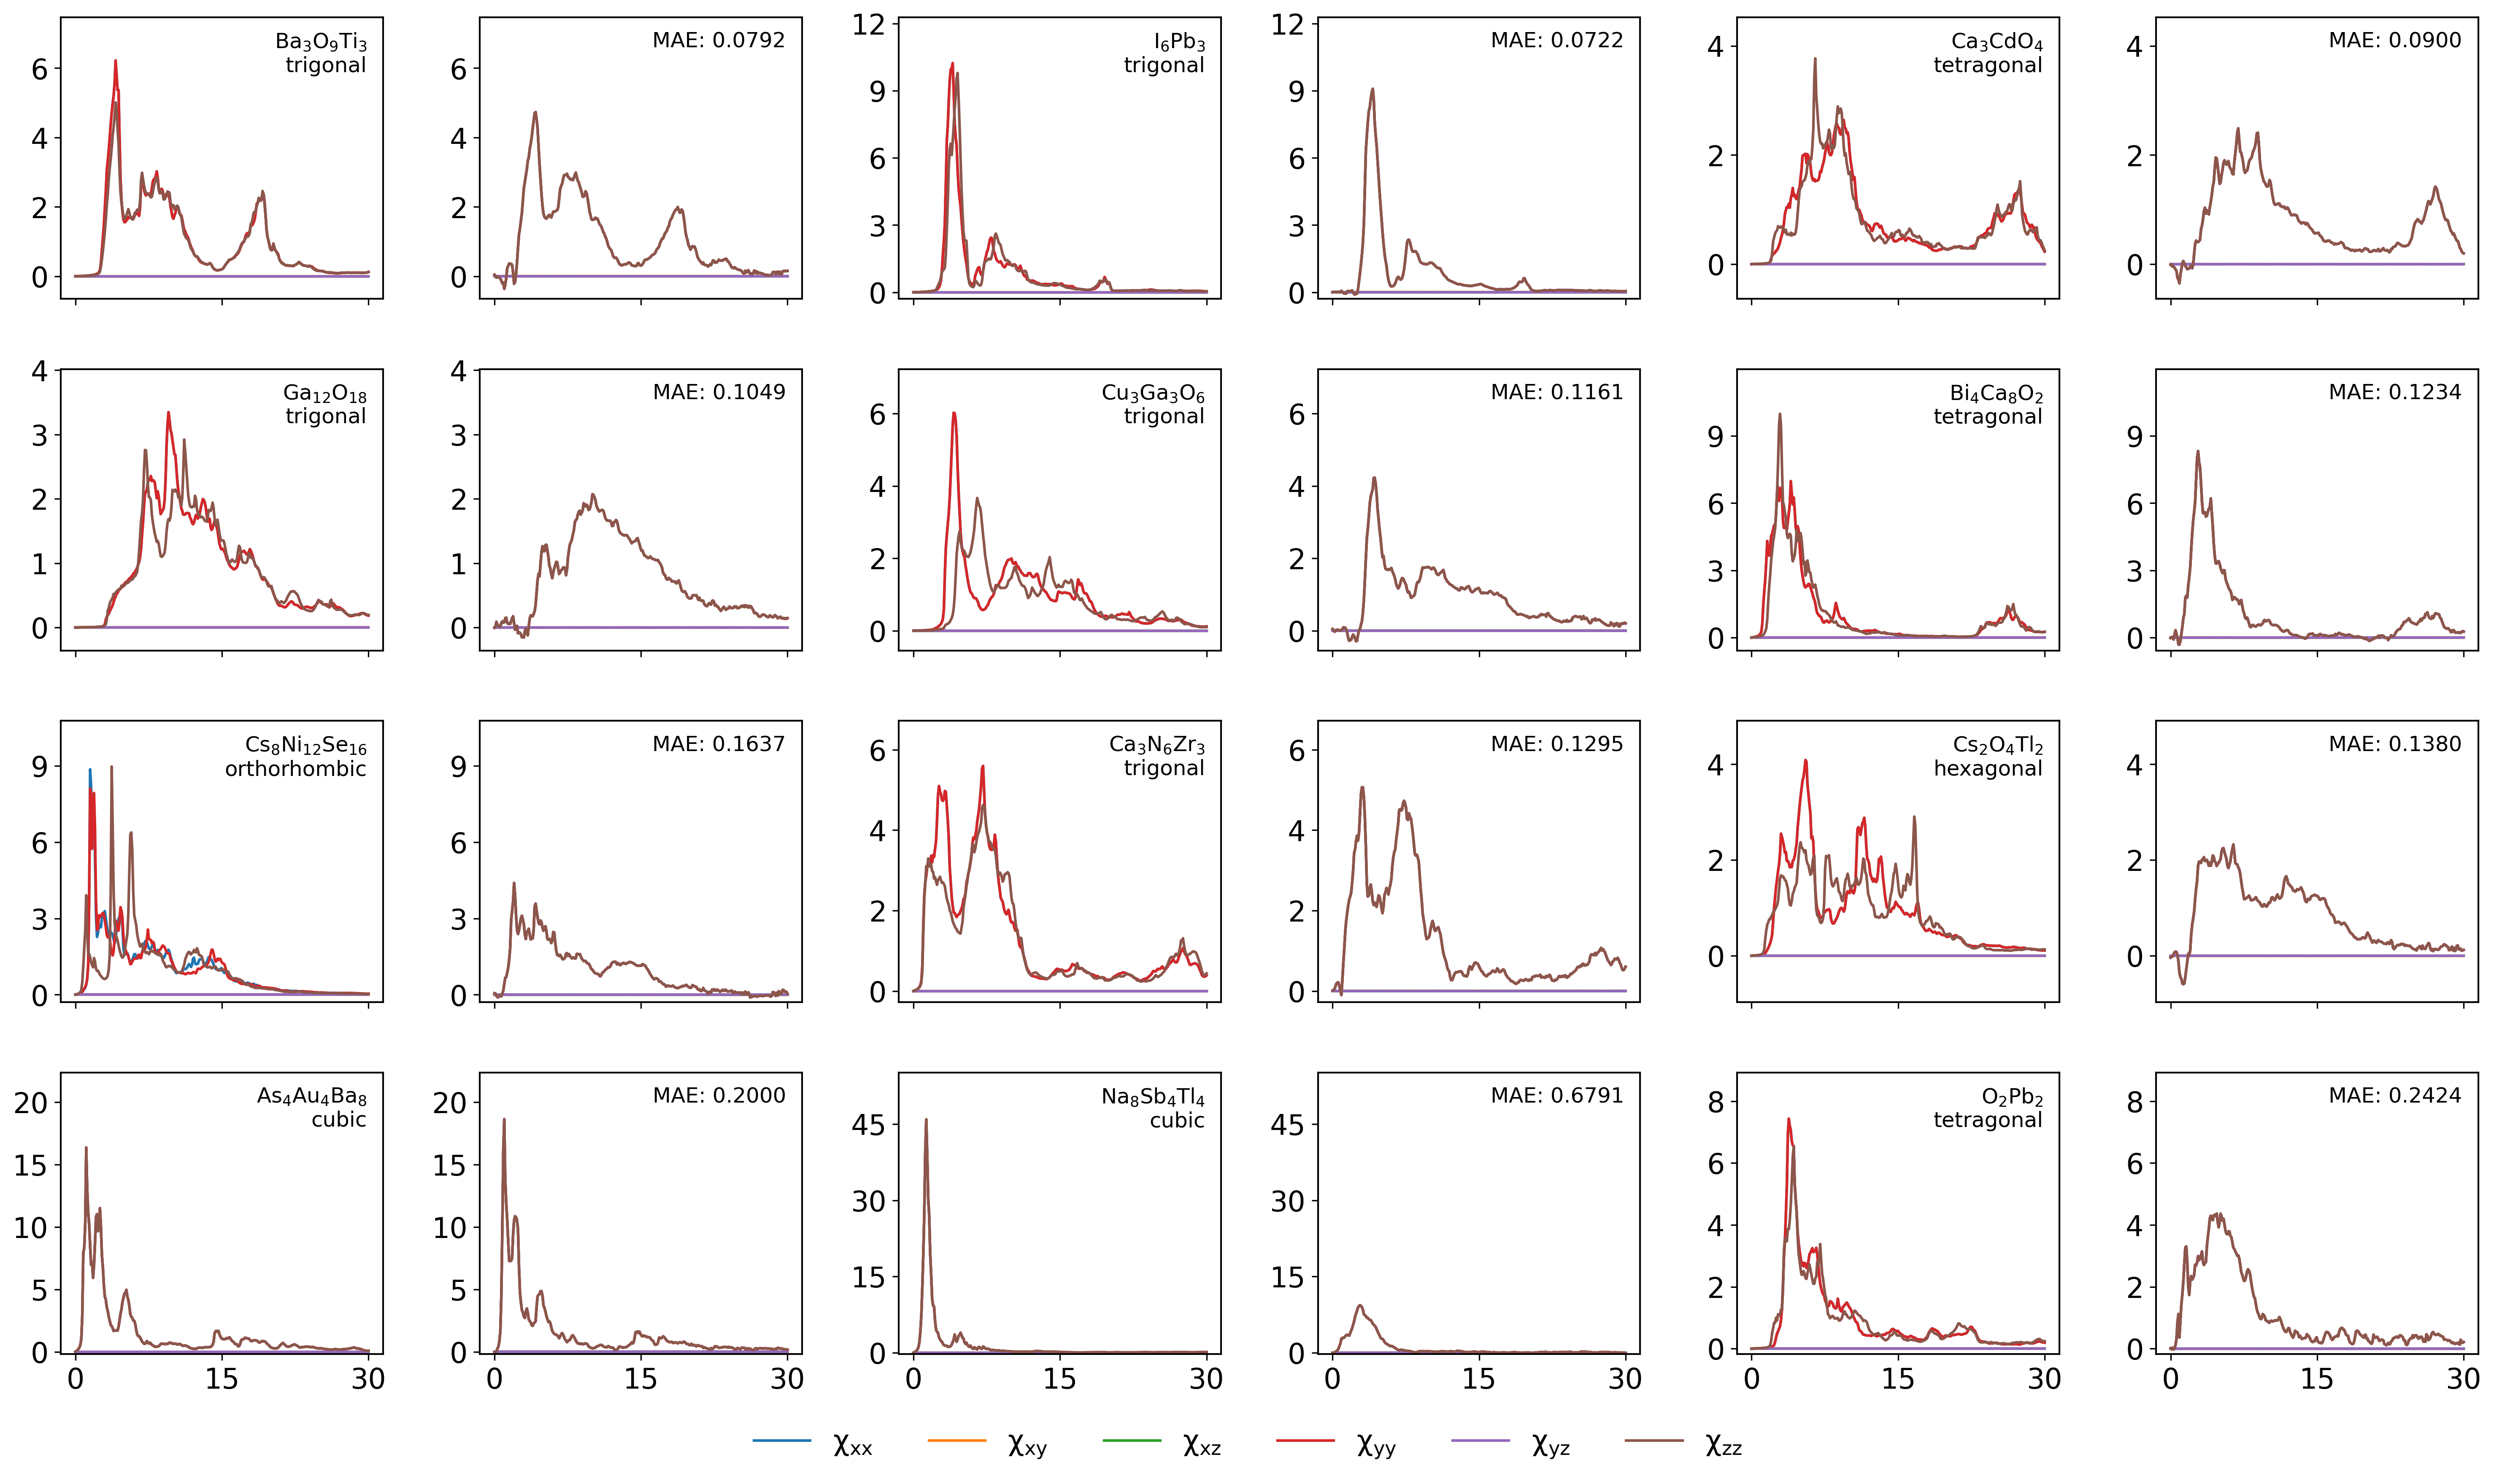

In [4]:
n_samples = 12
def sample_by_mae_quartiles(df, idx_test, n_per_quartile=3):
    """
    Robust quartile sampling from test set by `mae_cart` values.

    Returns:
        List of lists: Each sublist contains indices from one quartile.
    """
    df_test = df.loc[idx_test].copy()
    df_test = df_test.reset_index()

    # Try to divide into 4 bins (quartiles)
    try:
        df_test["mae_quartile"] = pd.qcut(
            df_test["mae_cart"].rank(method="first"), 
            q=4, 
            labels=False,
            duplicates="drop"
        )
    except ValueError as e:
        print("Warning:", e)
        return []

    grouped_indices = []
    for q in range(4):
        q_bin = df_test[df_test["mae_quartile"] == q]
        if len(q_bin) == 0:
            print(f"Skipping quartile {q} due to lack of data.")
            continue
        sampled = q_bin.sample(min(n_per_quartile, len(q_bin)), random_state=42)
        grouped_indices.append(sampled["index"].tolist())

    return grouped_indices

def plot_cartesian_tensor_comparison_by_quartile(df, grouped_idx, column_name, title_prefix=""):
    """
    Plots 3 samples per quartile in 4 rows (1 row per quartile), 6 subplots per row.

    Parameters:
    - grouped_idx: List of 4 sublists (each from a quartile)
    """
    xyz_list = ['x', 'y', 'z']
    tensor_components = [f"$\chi_{{{xyz_list[a]}{xyz_list[b]}}}$" for a in range(3) for b in range(a, 3)]
    total_samples = sum(len(g) for g in grouped_idx)

    fig, axes = plt.subplots(4, 6, figsize=(20, 12), dpi=300, sharex=True)
    axes = axes.reshape(4, 6)

    handles, labels = [], []
    sample_idx = 0

    for row_idx, quartile_group in enumerate(grouped_idx):
        for col_idx, idx_val in enumerate(quartile_group):
            ds_row = df.loc[idx_val]
            omega = ds_row["energies_interp"]
            real = ds_row[column_name]
            pred = ds_row["y_pred_cart"]
            formula = format_chemical_formula(ds_row["formula"])
            system = ds_row["crystal_system"]
            mae = ds_row["mae_cart"]

            y_min = min(real.min(), pred.min())
            y_max = max(real.max(), pred.max())

            ax_real = axes[row_idx, col_idx * 2]
            ax_pred = axes[row_idx, col_idx * 2 + 1]

            for i, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
                h, = ax_real.plot(omega, real[:, a, b], label=tensor_components[i])
                ax_pred.plot(omega, pred[:, a, b])
                if sample_idx == 0:
                    handles.append(h)
                    labels.append(tensor_components[i])

            for ax in (ax_real, ax_pred):
                ax.set_ylim((y_min - 0.1) * 1.4, y_max * 1.2)
                ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
                ax.set_xticks([])

            ax_real.text(0.95, 0.95, f"${formula}$\n{system}",
                         transform=ax_real.transAxes, fontsize=12, va='top', ha='right',
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            ax_pred.text(0.95, 0.95, f"MAE: {mae:.4f}",
                         transform=ax_pred.transAxes, fontsize=12, va='top', ha='right',
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            sample_idx += 1

    for ax in axes[-1, :]:
        ax.set_xticks(np.linspace(min(omega), max(omega), 3))

    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=6, fontsize=16, frameon=False)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.subplots_adjust(wspace=0.3, hspace=0.25)

    os.makedirs("../pngs", exist_ok=True)
    fig.savefig(f"../pngs/{title_prefix}_quartile_grid.png", dpi=300)
    plt.show()
grouped_idx = sample_by_mae_quartiles(df, idx_test, n_per_quartile=3)
plot_cartesian_tensor_comparison_by_quartile(df, grouped_idx, column_name=column, title_prefix="mae_quartiles")

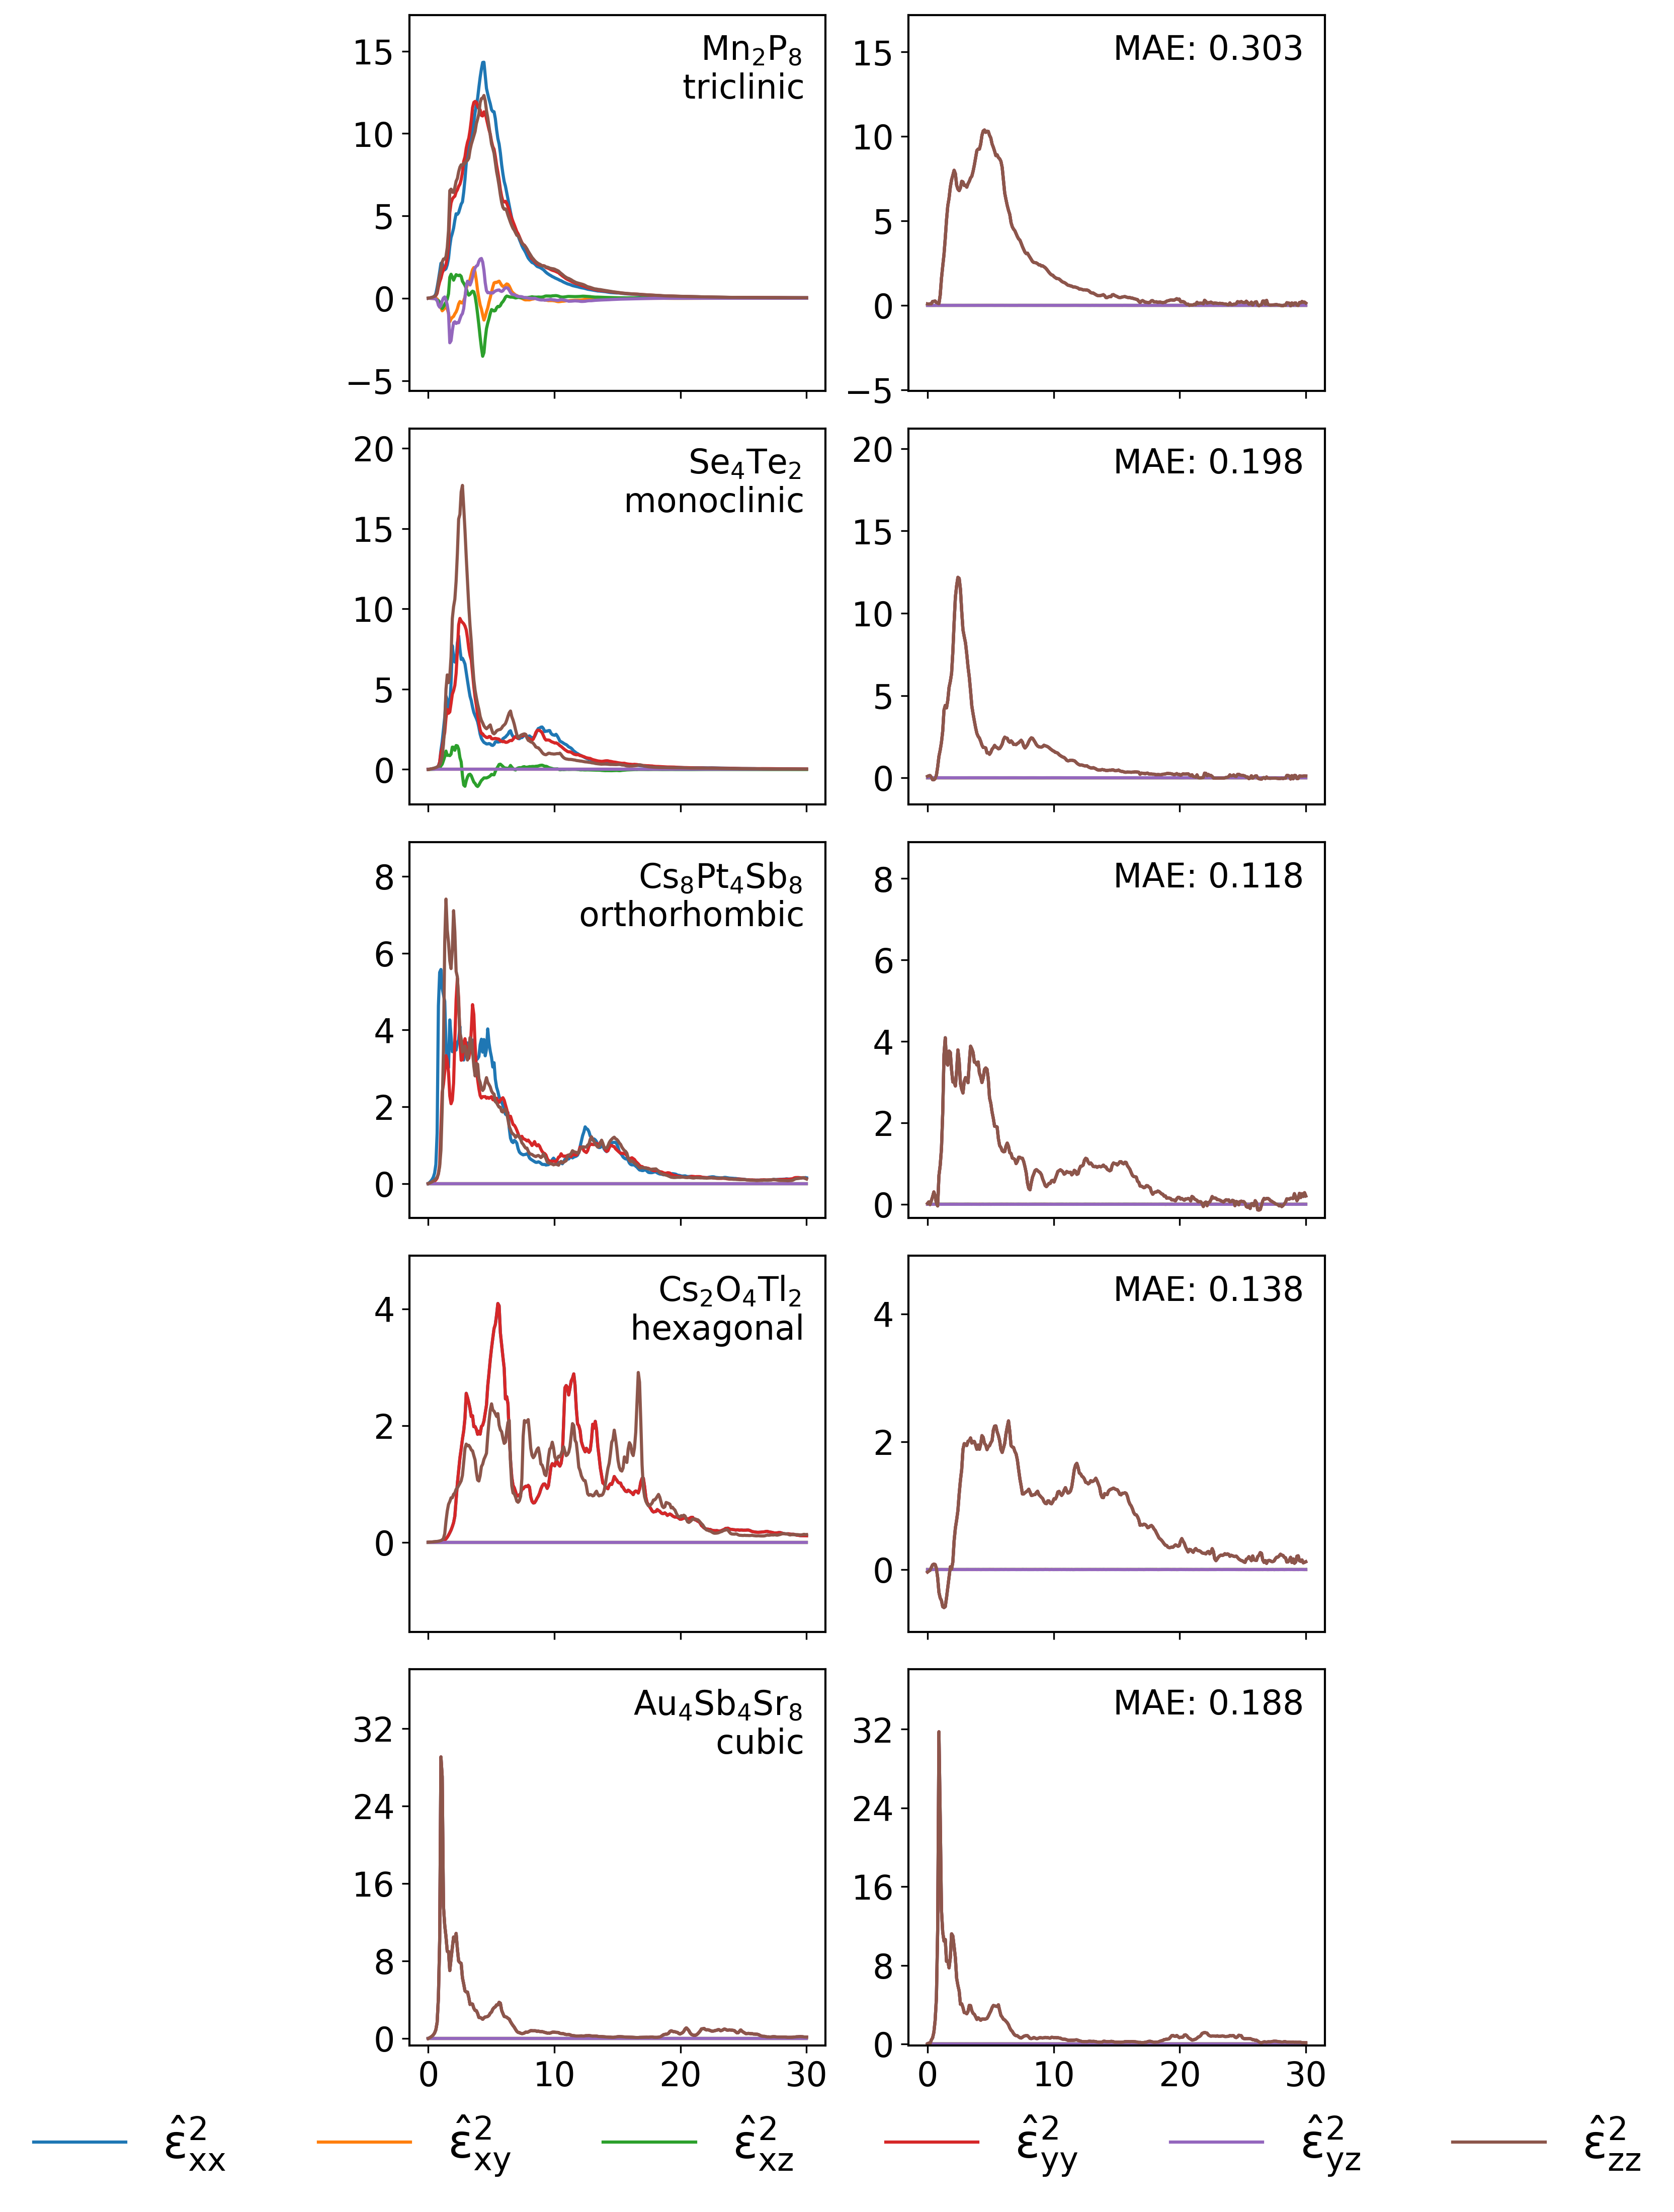

In [5]:
def get_one_sample_per_crystal_system(df, idx_test, target_systems):
    """
    Returns one index per crystal system from the test set, ordered from low to high symmetry.

    Parameters:
    - df: Full dataframe with 'crystal_system' column.
    - idx_test: List of indices belonging to the test set.
    - target_systems: List of crystal systems to include.

    Returns:
    - List of indices corresponding to one sample per crystal system, ordered by symmetry.
    """
    import random
    idx_test = list(idx_test)  # <-- COPY here, don't modify input!
    # random.seed(11)
    random.seed(24)
    random.shuffle(idx_test)

    # Define symmetry order from low to high
    symmetry_order = [
        "triclinic",
        "monoclinic",
        "orthorhombic",
        "tetragonal",
        "trigonal",
        "hexagonal",
        "cubic",
    ]

    # Filter the list to only those in target_systems, in the desired order
    ordered_targets = [s for s in symmetry_order if s in target_systems]

    # Create a lookup: crystal_system -> index
    system_to_index = {}
    seen_systems = set()

    for idx in idx_test:
        system = df.loc[idx, "crystal_system"]
        if system in ordered_targets and system not in seen_systems:
            system_to_index[system] = idx
            seen_systems.add(system)
        if len(seen_systems) == len(ordered_targets):
            break

    # Return indices in the desired symmetry order
    return [system_to_index[system] for system in ordered_targets if system in system_to_index]

    
    # return selected_indices
def plot_cartesian_tensor_comparison(df, idx, column_name, title_prefix="", n=3):
    """
    Plots multiple side-by-side line plots comparing predicted vs. real Cartesian tensors 
    in a more compact horizontal layout with minimal white space.

    Parameters:
    - df: Pandas DataFrame containing 'y_pred_cart' (predictions), 
          'real_Permittivity_Matrices_interp' (targets), and 'energies_interp'.
    - idx: List or array of indices to consider (e.g., idx_train, idx_test).
    - title_prefix: Prefix to be added to the plot title.
    - n: Number of samples to plot.
    """
    # Filter DataFrame based on provided indices
    ds = df.iloc[idx].reset_index(drop=True)

    # Define component labels
    xyz_list = ['x', 'y', 'z']
    tensor_components = [f"$\hat{{\epsilon}}^2_{{{xyz_list[a]}{xyz_list[b]}}}$" for a in range(3) for b in range(a, 3)]

    # Define subplot grid layout
    n_rows = 5
    n_cols = 2  
    # Adjust figure size to reduce white space
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows), dpi=300, sharex=True)
    axes = axes.ravel()  # Flatten axes array for easy iteration

    handles, labels = [], []

    for i, sample_idx in enumerate(idx[:n]):  # Directly loop over provided idx
        material_id = ds.iloc[i]['mp_id']
        mae_cart = ds.iloc[i]['mae_cart']
        
        crystal_system = ds.iloc[i]['crystal_system']
        formula = ds.iloc[i]['formula']
        omega = ds["energies_interp"].iloc[i]
        formatted_formula = format_chemical_formula(formula)
        real_permittivity = ds[column_name].iloc[i]  # (num_energies, 3, 3)
        pred_permittivity = ds["y_pred_cart"].iloc[i]  # (num_energies, 3, 3)
        
        y_min = min(real_permittivity.min(), pred_permittivity.min())
        y_max = max(real_permittivity.max(), pred_permittivity.max())
        
        # Left subplot: Real permittivity
        ax_real = axes[2 * i]  # Every even index is real data
        for idx, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
            h, = ax_real.plot(omega, real_permittivity[:, a, b], label=tensor_components[idx], linestyle='-')
            if i == 0:  # Collect legend items only from the first plot
                handles.append(h)
                labels.append(tensor_components[idx])
        if column_name =="real_Permittivity_Matrices_interp":
            ax_real.set_ylim((y_min-0.1) * 1.4, y_max * 1.2)
        else:
            ax_real.set_ylim((y_min-0.5) * 1.4, y_max * 1.2)
        ax_real.text(0.95, 0.95, f"${formatted_formula}$ \n {crystal_system}", 
             transform=ax_real.transAxes, fontsize=16, verticalalignment='top', 
             horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
        ax_real.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

        # Right subplot: Predicted permittivity
        ax_pred = axes[2 * i + 1]  # Every odd index is predicted data
        for idx, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
            ax_pred.plot(omega, pred_permittivity[:, a, b], linestyle='-')
        if column_name =="real_Permittivity_Matrices_interp":
            ax_pred.set_ylim((y_min-0.1) * 1.4, y_max * 1.2)
        else:
            ax_pred.set_ylim((y_min-0.1) * 1.4, y_max * 1.2)

        text_str = (
            f"{'MAE:':<1} {mae_cart:>4.3f}\n"
        )

        # Add the text to the subplot
        ax_pred.text(
            0.95, 0.95,  # Position in axes coordinates (top-right)
            text_str,
            transform=ax_pred.transAxes,
            fontsize=16,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
        )
        ax_pred.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        
    # Remove x-labels from individual subplots
    for ax in axes:
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=16)  # <-- Set the x-tick label size here
    for ax in axes[-n_cols:]:  
        ax.set_xticks(np.linspace(min(omega), max(omega), 4))
        ax.tick_params(axis='x', labelsize=16)  # <-- Set the x-tick label size here

    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=6, fontsize=22, frameon=False)
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout
    plt.subplots_adjust(wspace=0.2, hspace=0.1)  

    os.makedirs("../pngs", exist_ok=True)
    save_path = f"../pngs/{title_prefix}_cart_spectra.png"
    fig.savefig(save_path, dpi=300)

    plt.show()

target_systems = ['triclinic', 'monoclinic', 'orthorhombic', 'hexagonal', 'cubic']
representative_idx = get_one_sample_per_crystal_system(df, idx_test, target_systems)

# Then pass it to your plotting function
plot_cartesian_tensor_comparison(df, representative_idx, column_name=column, title_prefix="five_crystal_systems", n=5)



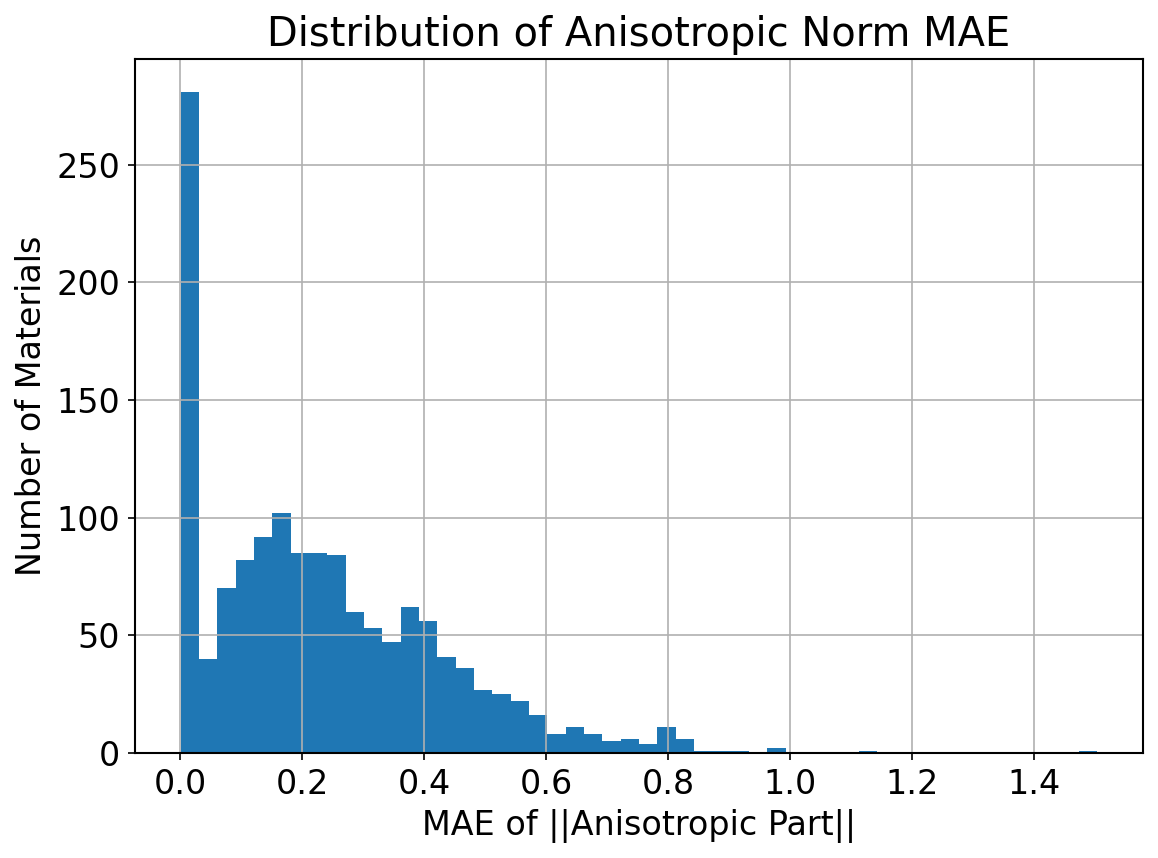

Mean MAE: 0.2319
Standard Deviation: 0.1973


In [6]:
def decompose_tensor_seq(tensor_seq):
    iso_parts = []
    aniso_parts = []
    for tensor in tensor_seq:
        iso, aniso = decompose_tensor((tensor + tensor.T.conj()) / 2)
        iso_parts.append(iso)
        aniso_parts.append(aniso)
    return np.array(iso_parts), np.array(aniso_parts)

def decompose_tensor(tensor):
    """
    Input: tensor of shape (3, 3)
    Returns: (iso_part, aniso_part), both (3, 3)
    """
    iso_scalar = np.trace(tensor) / 3
    iso_part = iso_scalar * np.eye(3)
    aniso_part = tensor - iso_part
    return iso_part, aniso_part

def anisotropy_strength(aniso_seq):
    return np.linalg.norm(aniso_seq, axis=(1,2))  # [n_freq]

def compute_aniso_mae(row):
    true_tensor = row["rel_permittivity_imag_interp"]
    pred_tensor = row["y_pred_cart"]

    true_iso, true_aniso = decompose_tensor_seq(true_tensor)
    pred_iso, pred_aniso = decompose_tensor_seq(pred_tensor)

    true_norm = anisotropy_strength(true_aniso)
    pred_norm = anisotropy_strength(pred_aniso)

    # Mask out invalid values
    mask = np.isfinite(true_norm) & np.isfinite(pred_norm)
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs(true_norm[mask] - pred_norm[mask]))

df['aniso_norm_mae'] = df.apply(compute_aniso_mae, axis=1)
plt.figure(figsize=(8, 6))
df['aniso_norm_mae'].dropna().hist(bins=50)
plt.xlabel("MAE of ||Anisotropic Part||")
plt.ylabel("Number of Materials")
plt.title("Distribution of Anisotropic Norm MAE")
plt.tight_layout()
plt.show()
mean_mae = df['aniso_norm_mae'].mean()
std_mae = df['aniso_norm_mae'].std()

print(f"Mean MAE: {mean_mae:.4f}")
print(f"Standard Deviation: {std_mae:.4f}")

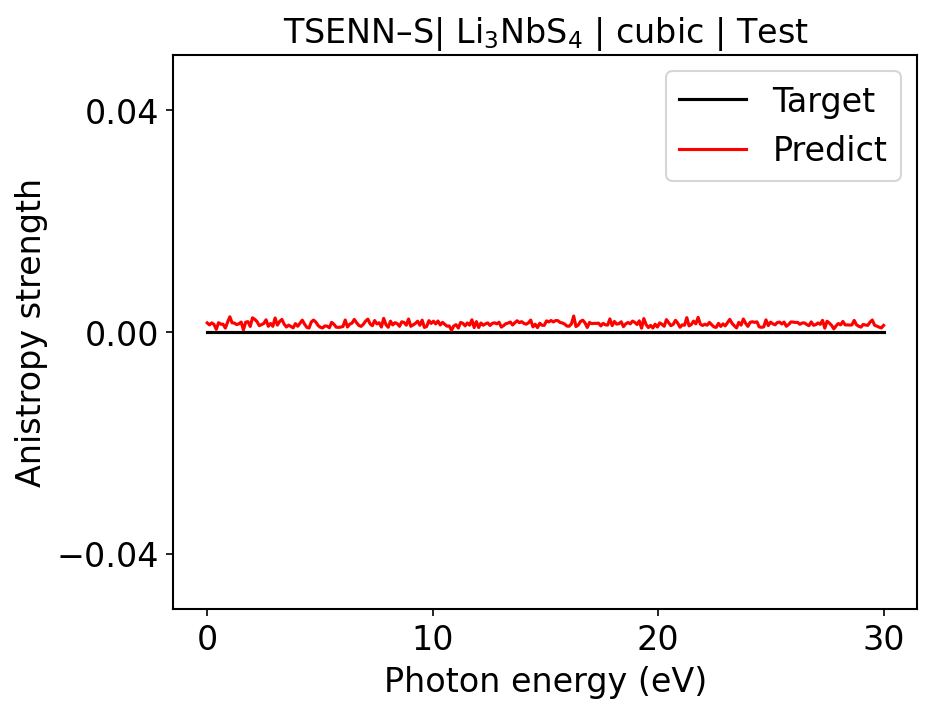

In [7]:
# row = df[df.formula == "K4O8Sb4"].iloc[0] # cubic
row = df.iloc[2]
# row = df.iloc[9] # monoclinic
true_tensor = row["rel_permittivity_imag_interp"]
pred_tensor = row["y_pred_cart"]

true_iso, true_aniso = decompose_tensor_seq(true_tensor)
pred_iso, pred_aniso = decompose_tensor_seq(pred_tensor)

true_norm = anisotropy_strength(true_aniso)
pred_norm = anisotropy_strength(pred_aniso)

# plt.title(f"{row.mp_id} | {row.crystal_system} | {row.split}")
# print(f"{row.mp_id} | {row.crystal_system} | {row.split}")
info_label = f"{row.mp_id} | {row.crystal_system} "
model_label = "TSENN–S"
fig, ax = plt.subplots()

plt.title(f"{model_label}| ${format_chemical_formula(row.formula)}$ | {row.crystal_system} | {row.split}", fontsize=16)

# plt.plot([], [], ' ', label=model_label)
# plt.plot([], [], ' ', label=info_label)  # dummy line for info
plt.plot(row.energies_interp, true_norm, label="Target", color='k')
plt.plot(row.energies_interp, pred_norm, label="Predict", color ='r')
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))
x_ticks = np.linspace(row.energies_interp[0], row.energies_interp[-1], 4)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{v:.0f}" for v in x_ticks])  # integer labels

ax.set_xlabel(r"Photon energy (eV)")
ax.set_ylabel("Anistropy strength")
ax.legend()
plt.ylim(-0.05,0.05)
plt.show()


/tmp/ipykernel_755320/148018997.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


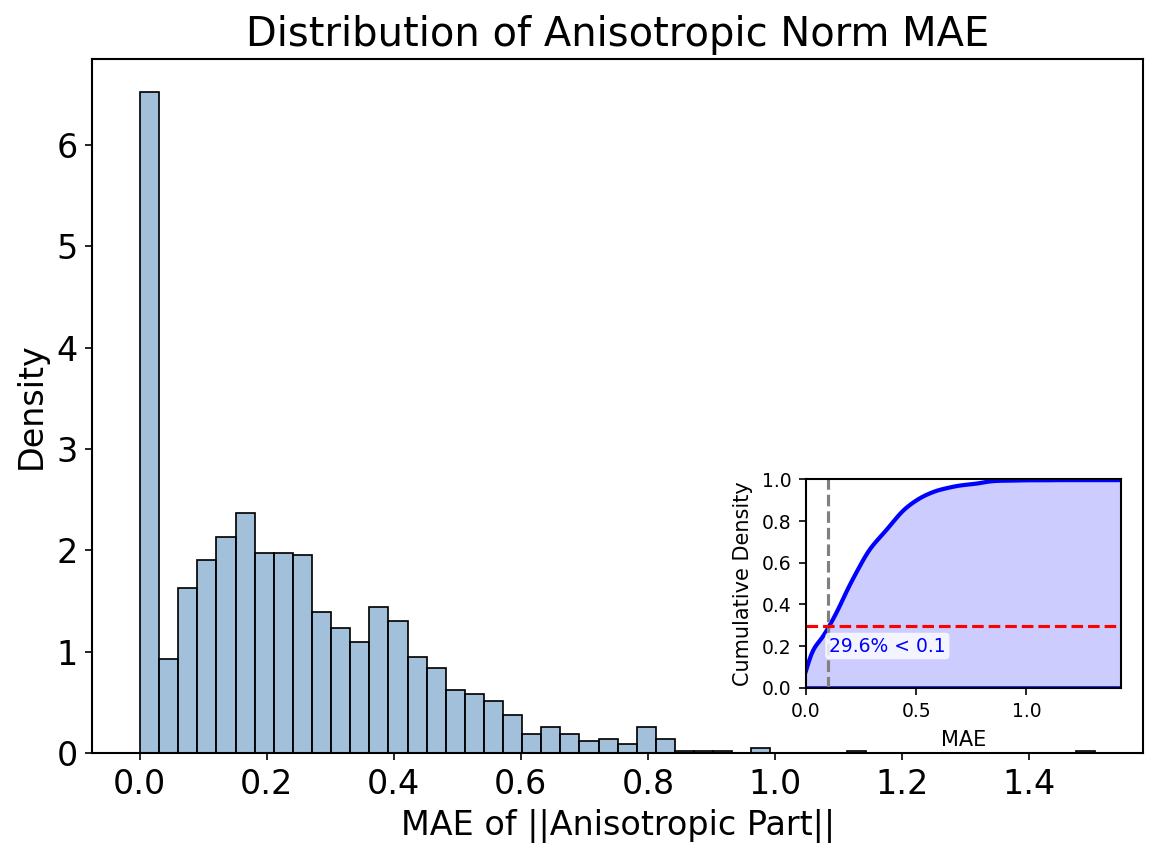

In [8]:
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import numpy as np

# Ensure clean data
aniso_mae = df['aniso_norm_mae'].dropna().values
threshold = 0.1

# Create main plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(aniso_mae, bins=50, stat='density', ax=ax, color='steelblue', alpha=0.5)
ax.set_xlabel("MAE of ||Anisotropic Part||")
ax.set_ylabel("Density")
ax.set_title("Distribution of Anisotropic Norm MAE")

# Create inset axes
inset_ax = inset_axes(ax, width="30%", height="30%", loc='lower right', 
                      bbox_to_anchor=(-0.005, 0.07, 1, 1), bbox_transform=ax.transAxes)

# KDE CDF
sns.kdeplot(aniso_mae, ax=inset_ax, color='blue', fill=True, cumulative=True,
            bw_adjust=0.5, alpha=0.2, linewidth=2)

# Axes settings
inset_ax.set_xlabel("MAE", fontsize=10)
inset_ax.set_ylabel("Cumulative Density", fontsize=10)
inset_ax.tick_params(axis='both', labelsize=9)
inset_ax.set_xlim(0, np.max(aniso_mae) * 0.95)
inset_ax.set_ylim(0, 1)

# Compute % below threshold
perc_below = np.mean(aniso_mae < threshold) * 100
inset_ax.axvline(x=threshold, color='gray', linestyle='--', linewidth=1.5)
inset_ax.axhline(y=perc_below / 100, color='red', linestyle='--', linewidth=1.5)

inset_ax.text(threshold + 0.005, perc_below / 100 - 0.05,
              f'{perc_below:.1f}% < {threshold}',
              color='blue', fontsize=9, ha='left', va='top',
              bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()


In [9]:
df_train = df.loc[idx_train].copy().reset_index()
df_valid = df.loc[idx_valid].copy().reset_index()
df_test = df.loc[idx_test].copy().reset_index()

# print(df_train['mae_cart'].mean())
# print(df_valid['mae_cart'].mean())
print(f"mean MAE", df_test['mae_cart'].mean(), f"median MAE", df_test['mae_cart'].median())

threshold = 0.3

def density_below_threshold(series, threshold):
    """Return fraction of values <= threshold"""
    return (series <= threshold).mean()

print(f"mean mae_cart_xx",df_test['mae_cart_xx'].mean(), f"mean mae_cart_xx", df_test['mae_cart_xx'].median())
print(f"mean mae_cart_yy",df_test['mae_cart_yy'].mean(), f"medin mae_cart_yy", df_test['mae_cart_yy'].median())
print(f"mean mae_cart_zz",df_test['mae_cart_zz'].mean(), f"median mae_cart_zz", df_test['mae_cart_zz'].median())
df_xz = df_test[df_test["crystal_system"].isin(["monoclinic", "triclinic"])]
mean_mae_xz = df_xz["mae_cart_xz"].mean()
median_mae_xz = df_xz["mae_cart_xz"].median()
print(f"mean mae_cart_xz: {mean_mae_xz:.4f}")
print(f"median mae_cart_xz: {median_mae_xz:.4f}")

df_xy = df_test[df_test["crystal_system"].isin(["triclinic"])]
mean_mae_xy = df_xy["mae_cart_xy"].mean()
median_mae_xy = df_xy["mae_cart_xy"].median()
print(f"mean mae_cart_xy: {mean_mae_xy:.4f}")
print(f"median mae_cart_xy: {median_mae_xy:.4f}")

df_yz = df_test[df_test["crystal_system"].isin(["triclinic"])]
mean_mae_yz = df_yz["mae_cart_yz"].mean()
median_mae_yz = df_yz["mae_cart_yz"].median()
print(f"mean mae_cart_yz: {mean_mae_yz:.4f}")
print(f"median mae_cart_yz: {median_mae_yz:.4f}")



print("=== Density of samples with MAE ≤ 0.1 ===")
print(f"mae_cart      : {density_below_threshold(df_test['mae_cart'], threshold):.3f}")
print(f"mae_cart_xx   : {density_below_threshold(df_test['mae_cart_xx'], threshold):.3f}")
print(f"mae_cart_yy   : {density_below_threshold(df_test['mae_cart_yy'], threshold):.3f}")
print(f"mae_cart_zz   : {density_below_threshold(df_test['mae_cart_zz'], threshold):.3f}")

print(f"mae_cart_xz   : {density_below_threshold(df_xz['mae_cart_xz'], threshold):.3f}")
print(f"mae_cart_xy   : {density_below_threshold(df_xy['mae_cart_xy'], threshold):.3f}")
print(f"mae_cart_yz   : {density_below_threshold(df_yz['mae_cart_yz'], threshold):.3f}")


def mae_cart_norm(row):
    xx, yy, zz = row["mae_cart_xx"], row["mae_cart_yy"], row["mae_cart_zz"]
    xy, xz, yz = row.get("mae_cart_xy", 0.0), row.get("mae_cart_xz", 0.0), row.get("mae_cart_yz", 0.0)
    return np.sqrt(xx**2 + yy**2 + zz**2 + 2*(xy**2 + xz**2 + yz**2))

df_test["mae_cart_norm"] = df_test.apply(mae_cart_norm, axis=1)

# Now compute density under 0.1 threshold
threshold = 0.1
density_norm = (df_test["mae_cart"] <= threshold).mean()

print("=== Density of samples with ||mae_cart|| ≤ 0.1 ===")
print(f"mae_cart_norm : {density_norm* 100:.3f} %")

mean MAE 0.15414209069224893 median MAE 0.1234420946042284
mean mae_cart_xx 0.30371288964328774 mean mae_cart_xx 0.2389200828879977
mean mae_cart_yy 0.28541434386602277 medin mae_cart_yy 0.22710829957480466
mean mae_cart_zz 0.3170070686889381 median mae_cart_zz 0.258772791013995
mean mae_cart_xz: 0.0816
median mae_cart_xz: 0.0736
mean mae_cart_xy: 0.0902
median mae_cart_xy: 0.0881
mean mae_cart_yz: 0.1263
median mae_cart_yz: 0.1270
=== Density of samples with MAE ≤ 0.1 ===
mae_cart      : 0.925
mae_cart_xx   : 0.680
mae_cart_yy   : 0.701
mae_cart_zz   : 0.585
mae_cart_xz   : 1.000
mae_cart_xy   : 1.000
mae_cart_yz   : 1.000
=== Density of samples with ||mae_cart|| ≤ 0.1 ===
mae_cart_norm : 35.374 %


In [10]:
comp_labels = ["xx", "yy", "zz", "xy", "xz", "yz"]
triu_idx = [(0,0), (1,1), (2,2), (0,1), (0,2), (1,2)]

# --- Step 1: compute per-component maxima ---
def per_component_max(row):
    tensor = row["rel_permittivity_imag"]  # shape (N_ω, 3, 3)
    results = {}
    for (i, j), lbl in zip(triu_idx, comp_labels):
        results[f"true_max_{lbl}"] = np.nanmax(np.abs(tensor[:, i, j]))
    return pd.Series(results)

df_true_max = df.apply(per_component_max, axis=1)
for col in df_true_max.columns:
    df[col] = df_true_max[col]

# --- Step 2: subset test data ---
df_test = df.loc[idx_test].copy().reset_index()

# --- Step 3: diagonals (always present) ---
for lbl in ["xx", "yy", "zz"]:
    mean_val   = df_test[f"true_max_{lbl}"].mean()
    median_val = df_test[f"true_max_{lbl}"].median()
    print(f"{lbl}: mean of maxima = {mean_val:.4f}, median of maxima = {median_val:.4f}")

# --- Step 4: xz (monoclinic & triclinic only) ---
df_xz = df_test[df_test["crystal_system"].isin(["monoclinic", "triclinic"])]
mean_val   = df_xz["true_max_xz"].mean()
median_val = df_xz["true_max_xz"].median()
print(f"xz: mean of maxima = {mean_val:.4f}, median of maxima = {median_val:.4f}")

# --- Step 5: xy (triclinic only) ---
df_xy = df_test[df_test["crystal_system"] == "triclinic"]
mean_val   = df_xy["true_max_xy"].mean()
median_val = df_xy["true_max_xy"].median()
print(f"xy: mean of maxima = {mean_val:.4f}, median of maxima = {median_val:.4f}")

# --- Step 6: yz (triclinic only) ---
df_yz = df_test[df_test["crystal_system"] == "triclinic"]
mean_val   = df_yz["true_max_yz"].mean()
median_val = df_yz["true_max_yz"].median()
print(f"yz: mean of maxima = {mean_val:.4f}, median of maxima = {median_val:.4f}")
df_xz = df_test[df_test["crystal_system"].isin(["monoclinic", "triclinic"])]
mean_val   = df_xz["true_max_xz"].mean()
median_val = df_xz["true_max_xz"].median()
mean_mae_xz = df_xz["mae_cart_xz"].mean()
median_mae_xz = df_xz["mae_cart_xz"].median()

print("ratio", mean_mae_xz/mean_val * 100, median_mae_xz/median_val *100)

xx: mean of maxima = 8.6812, median of maxima = 6.2683
yy: mean of maxima = 8.3198, median of maxima = 6.0597
zz: mean of maxima = 8.6310, median of maxima = 6.3290
xz: mean of maxima = 1.1135, median of maxima = 0.9620
xy: mean of maxima = 1.6821, median of maxima = 1.0543
yz: mean of maxima = 1.4888, median of maxima = 1.2270
ratio 7.324129848928693 7.649840824431774


In [11]:
comp_labels = ["xx", "yy", "zz", "xy", "xz", "yz"]
triu_idx = [(0,0), (1,1), (2,2), (0,1), (0,2), (1,2)]

# --- Step 1: compute per-component maxima ---
def per_component_max(row):
    tensor = row["rel_permittivity_imag_interp"]  # shape (N_ω, 3, 3)
    results = {}
    for (i, j), lbl in zip(triu_idx, comp_labels):
        results[f"true_max_{lbl}"] = np.nanmax(np.abs(tensor[:, i, j]))
    return pd.Series(results)

df_true_max = df.apply(per_component_max, axis=1)
for col in df_true_max.columns:
    df[col] = df_true_max[col]

# --- Step 2: subset test data ---
df_test = df.loc[idx_test].copy().reset_index()

# --- Helper: stratify by symmetry ---
def get_subset(df, comp):
    if comp in ["xx", "yy", "zz"]:
        return df
    elif comp == "xz":
        return df[df["crystal_system"].isin(["monoclinic", "triclinic"])]
    elif comp in ["xy", "yz"]:
        return df[df["crystal_system"] == "triclinic"]
    return df

# --- Step 3: compute relative errors ---
print("Contrast errors (mean/median MAE divided by mean/median max, in %):")
for lbl in comp_labels:
    subset = get_subset(df_test, lbl)
    if len(subset) == 0:
        continue

    mean_max   = subset[f"true_max_{lbl}"].mean()
    median_max = subset[f"true_max_{lbl}"].median()
    mean_mae   = subset[f"mae_cart_{lbl}"].mean()
    median_mae = subset[f"mae_cart_{lbl}"].median()

    rel_mean   = mean_mae / mean_max * 100 if mean_max > 0 else np.nan
    rel_median = median_mae / median_max * 100 if median_max > 0 else np.nan

    print(f"{lbl}: rel_mean = {rel_mean:.1f}%, rel_median = {rel_median:.1f}%")

Contrast errors (mean/median MAE divided by mean/median max, in %):
xx: rel_mean = 3.6%, rel_median = 3.9%
yy: rel_mean = 3.5%, rel_median = 3.8%
zz: rel_mean = 3.7%, rel_median = 4.1%
xy: rel_mean = 5.4%, rel_median = 8.5%
xz: rel_mean = 7.5%, rel_median = 8.0%
yz: rel_mean = 9.0%, rel_median = 10.7%


In [ ]:
comp_labels = ["xx", "yy", "zz", "xy", "xz", "yz"]
triu_idx = [(0,0), (1,1), (2,2), (0,1), (0,2), (1,2)]

# --- Step 1: compute per-component maxima ---
def per_component_max(row):
    tensor = row["rel_permittivity_imag_interp"]  # shape (N_ω, 3, 3)
    results = {}
    for (i, j), lbl in zip(triu_idx, comp_labels):
        results[f"true_max_{lbl}"] = np.nanmax(np.abs(tensor[:, i, j]))
    return pd.Series(results)

df_true_max = df.apply(per_component_max, axis=1)
for col in df_true_max.columns:
    df[col] = df_true_max[col]

# --- Step 2: subset test data ---
df_test = df.loc[idx_test].copy().reset_index()

# --- Helper: stratify by symmetry ---
def get_subset(df, comp):
    if comp in ["xx", "yy", "zz"]:
        return df
    elif comp == "xz":
        return df[df["crystal_system"].isin(["monoclinic", "triclinic"])]
    elif comp in ["xy", "yz"]:
        return df[df["crystal_system"] == "triclinic"]
    return df

# --- Step 3: compute relative errors ---
print("Contrast errors (mean/median MAE divided by mean/median max, in %):")
for lbl in comp_labels:
    subset = get_subset(df_test, lbl)
    if len(subset) == 0:
        continue
    # print(lbl, subset[f"true_max_{lbl}"].mean())
    mean_max   = subset[f"true_max_{lbl}"].mean()
    median_max = subset[f"true_max_{lbl}"].median()
    mean_mae   = subset[f"mae_cart_{lbl}"].mean()
    median_mae = subset[f"mae_cart_{lbl}"].median()

    rel_mean   = mean_mae / mean_max * 100 if mean_max > 0 else np.nan
    rel_median = median_mae / median_max * 100 if median_max > 0 else np.nan

    print(f"{lbl}: rel_mean = {rel_mean:.1f}%, rel_median = {rel_median:.1f}%")

Contrast errors (mean/median MAE divided by mean/median max, in %):
xx: rel_mean = 15.8%, rel_median = 3.5%
yy: rel_mean = 12.6%, rel_median = 3.0%
zz: rel_mean = 12.0%, rel_median = 4.4%
xy: rel_mean = 5.7%, rel_median = 7.3%
xz: rel_mean = 4.6%, rel_median = 2.6%
yz: rel_mean = 8.0%, rel_median = 6.7%
